# Regressão Linear com PyTorch - Dataset House Sales


## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).


Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação


## Importação dos pacotes

In [163]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [164]:
!pwd

/content


In [165]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip\
 https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  3249k      0 --:--:-- --:--:-- --:--:-- 3249k


In [166]:
!unzip -o /content/housesalesprediction.zip


Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [167]:
# Load the dataset
df = pd.read_csv('/content/kc_house_data.csv')


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [169]:
df = df.drop(['id', 'date'], axis=1)


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [171]:
y = df['price'].values.reshape(-1, 1)


In [172]:
y

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

In [173]:
y.shape

(21613, 1)

In [174]:
X = df.drop('price', axis=1).values

In [175]:
X.shape

(21613, 18)

### Normalização dos dados

In [176]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [177]:
x_scaler

StandardScaler()

In [178]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


In [179]:
X.shape[1]

18

## Criação do modelo da rede

In [180]:
model = torch.nn.Linear(18, 1)

### Verificando a inicialização dos parâmetros

In [181]:
model.weight.data

tensor([[-0.2220, -0.0462, -0.1132, -0.0629, -0.2082,  0.0946, -0.2113, -0.0150,
          0.0819, -0.0794,  0.1337,  0.0297,  0.1296,  0.1512, -0.1041,  0.0857,
         -0.1020,  0.0739]])

### Testando o predict da rede

In [182]:
model(torch.ones(5,18))

tensor([[-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072],
        [-0.5072]], grad_fn=<AddmmBackward0>)

In [183]:
model(X_train_tensor[:3])

tensor([[-0.8767],
        [ 0.1813],
        [-0.6099]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [184]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 400


### Laço de treinamento

In [185]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [186]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [187]:

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)


    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/400], Train Loss: 0.546408, Val Loss: 0.498613
Epoch[4/400], Train Loss: 0.399865, Val Loss: 0.414205
Epoch[6/400], Train Loss: 0.353450, Val Loss: 0.378457
Epoch[8/400], Train Loss: 0.330735, Val Loss: 0.358771
Epoch[10/400], Train Loss: 0.317577, Val Loss: 0.346797
Epoch[12/400], Train Loss: 0.309371, Val Loss: 0.339124
Epoch[14/400], Train Loss: 0.304011, Val Loss: 0.334025
Epoch[16/400], Train Loss: 0.300390, Val Loss: 0.330544
Epoch[18/400], Train Loss: 0.297880, Val Loss: 0.328118
Epoch[20/400], Train Loss: 0.296107, Val Loss: 0.326401
Epoch[22/400], Train Loss: 0.294837, Val Loss: 0.325172
Epoch[24/400], Train Loss: 0.293917, Val Loss: 0.324285
Epoch[26/400], Train Loss: 0.293245, Val Loss: 0.323640
Epoch[28/400], Train Loss: 0.292751, Val Loss: 0.323168
Epoch[30/400], Train Loss: 0.292386, Val Loss: 0.322822
Epoch[32/400], Train Loss: 0.292114, Val Loss: 0.322568
Epoch[34/400], Train Loss: 0.291912, Val Loss: 0.322380
Epoch[36/400], Train Loss: 0.291760, Val Loss: 0.322

## Avaliação

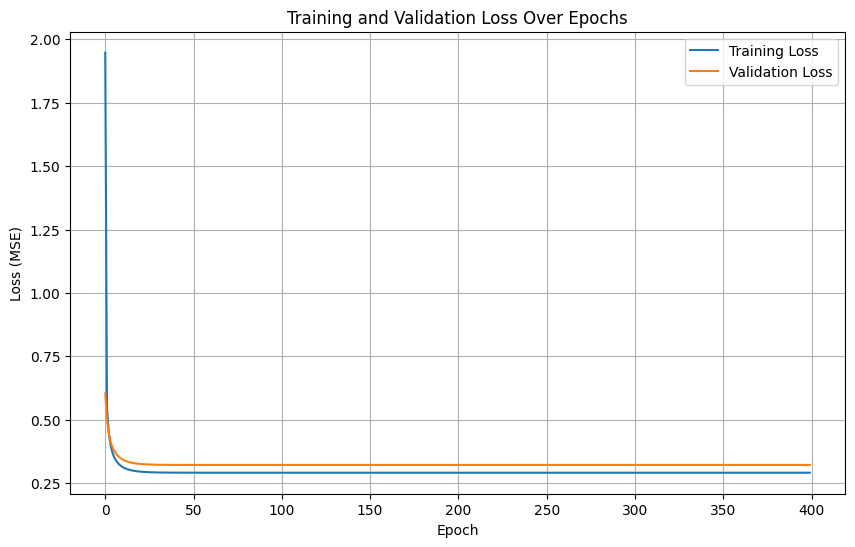

In [188]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()